In [1]:
from transformers import VivitModel
import json
import torch
from torch.utils.data import Dataset, DataLoader
import av
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os

In [2]:
with open("data/annotations/proficiency_demonstrator_train.json", "r") as file:
    proficiency_metadata = json.load(file)["annotations"]

In [13]:
class VideoDataset(Dataset):
    def __init__(self, proficiency_metadata, video_type='ego', num_frames=32, size=224, train=True):
        self.paths, self.targets = [], []
        for m in proficiency_metadata:
            video_path = m['video_paths'][video_type].split('/')
            video_path[-1:-1] = ['downscaled', '448']
            video_path = f"data/{'/'.join(video_path)}"
            if os.path.exists(video_path):
                self.paths.append(video_path)
                self.targets.append(m['proficiency_score'])
        levels = ["Novice", "Early Expert", "Intermediate Expert", "Late Expert"]
        self.level_to_idx = {s: i for i, s in enumerate(levels)}
        self.targets = torch.tensor([self.level_to_idx[s] for s in self.targets], dtype=torch.long)
        self.num_frames, self.size, self.train = num_frames, size, train
        # ViViT's processor normalizes with mean=0.5, std=0.5
        self.mean = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)
        self.std = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)

    def __len__(self):
        return len(self.paths)

    def _indices(self, n):
        if self.train:  # random temporal jitter within uniform segments
            edges = torch.linspace(0, n, self.num_frames + 1)
            idx = (edges[:-1] + torch.rand(self.num_frames) * (edges[1:] - edges[:-1])).long()
        else:           # deterministic uniform sampling
            idx = torch.linspace(0, n - 1, self.num_frames).long()
        return idx.clamp(max=n - 1).tolist()

    def __getitem__(self, i):
        with av.open(self.paths[i]) as container:
            stream = container.streams.video[0]
            n = stream.frames or sum(1 for _ in container.demux(stream))  # fallback if frame count is missing
            container.seek(0)
            wanted = set(self._indices(n))
            frames = [
                torch.from_numpy(f.to_ndarray(format="rgb24"))
                for k, f in enumerate(container.decode(stream)) if k in wanted
            ]
        x = torch.stack(frames).permute(0, 3, 1, 2)            # (T, C, H, W) uint8
        x = torch.nn.functional.interpolate(
            x.float(), size=(self.size, self.size), mode="bilinear", antialias=True, align_corners=False
        )
        x = (x / 255.0 - self.mean) / self.std
        return x, self.targets[i]


In [4]:
ds = VideoDataset(proficiency_metadata[:100], train=False)
loader = DataLoader(ds, batch_size=4, shuffle=False, num_workers=0,
                    pin_memory=True)

In [5]:
model = VivitModel.from_pretrained("google/vivit-b-16x2-kinetics400", device_map="auto")

Some weights of VivitModel were not initialized from the model checkpoint at google/vivit-b-16x2-kinetics400 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
outputs = []
targets = []
with torch.inference_mode():
    for x_batch, y_batch in tqdm(loader):
        x = x_batch.to(model.device, non_blocking=True)
        out = model(pixel_values=x)
        outputs.append(out.last_hidden_state.cpu())
        targets.append(y_batch)

features = torch.cat(outputs)   # (N, 3137, 768)
targets = torch.cat(targets)

  0%|          | 0/22 [00:00<?, ?it/s]c:\Users\darkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 22/22 [03:45<00:00, 10.23s/it]


In [7]:
torch.save(features, "vivit_features_100.pt")
torch.save(targets, "vivit_targets_100.pt")

c:\Users\darkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\darkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\darkn\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\darkn\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

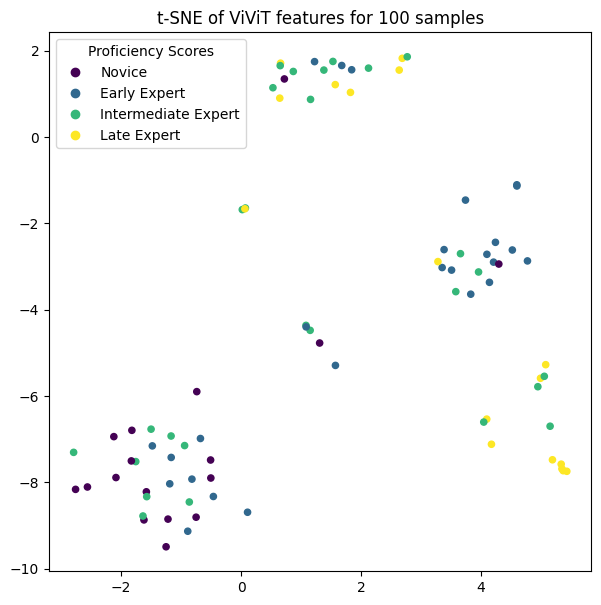

In [8]:
# features: (N, 3137, 768) torch tensor
emb = features[:, 0].float().numpy()               # CLS token, (N, 768)
# or: emb = features[:, 1:].mean(dim=1).float().numpy()   # mean of patch tokens

tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(emb) - 1),   # must be < N
    init="pca",
    learning_rate="auto",
    random_state=0,
)
coords = tsne.fit_transform(emb)                   # (N, 2)

plt.figure(figsize=(7, 7))
class_names = ["Novice", "Early Expert", "Intermediate Expert", "Late Expert"]
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=targets, s=20)
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=class_names, title="Proficiency Scores")
plt.title("t-SNE of ViViT features for 100 samples")
plt.savefig("vivit_tsne_100.png")
plt.show()



In [9]:
ds = VideoDataset(proficiency_metadata, train=False)
loader = DataLoader(ds, batch_size=4, shuffle=False, num_workers=0,
                    pin_memory=True)

In [10]:
outputs = []
targets = []
with torch.inference_mode():
    for x_batch, y_batch in tqdm(loader):
        x = x_batch.to(model.device, non_blocking=True)
        out = model(pixel_values=x)
        outputs.append(out.last_hidden_state.cpu())
        targets.append(y_batch)

features = torch.cat(outputs)   # (N, 3137, 768)
targets = torch.cat(targets)

  0%|          | 0/414 [00:00<?, ?it/s]c:\Users\darkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 414/414 [1:12:26<00:00, 10.50s/it]


In [11]:
torch.save(features, "vivit_features.pt")
torch.save(targets, "vivit_targets.pt")

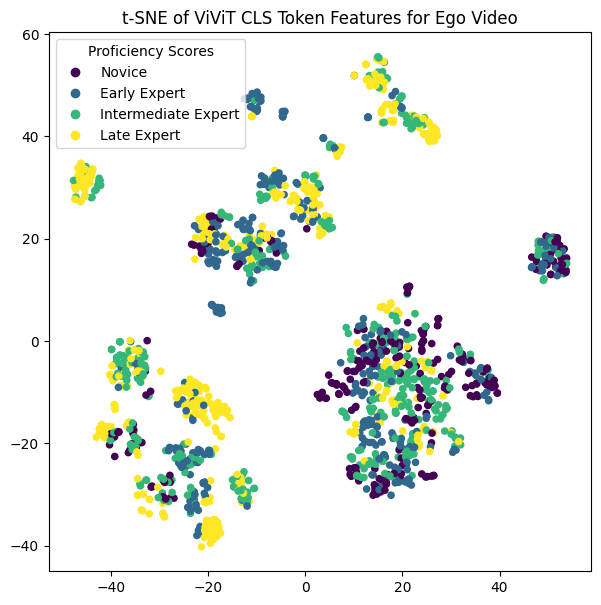

In [17]:
features = torch.load("vivit_features.pt")
targets = torch.load("vivit_targets.pt")

# features: (N, 3137, 768) torch tensor
emb = features[:, 0].float().numpy()               # CLS token, (N, 768)
# emb = features[:, 1:].mean(dim=1).float().numpy()   # mean of patch tokens

tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(emb) - 1),   # must be < N
    init="pca",
    learning_rate="auto",
    random_state=0,
)
coords = tsne.fit_transform(emb)                   # (N, 2)

plt.figure(figsize=(7, 7))
class_names = ["Novice", "Early Expert", "Intermediate Expert", "Late Expert"]
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=targets, s=20)
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=class_names, title="Proficiency Scores")
plt.title("t-SNE of ViViT CLS Token Features for Ego Video")
plt.savefig("vivit_tsne.png")
plt.show()


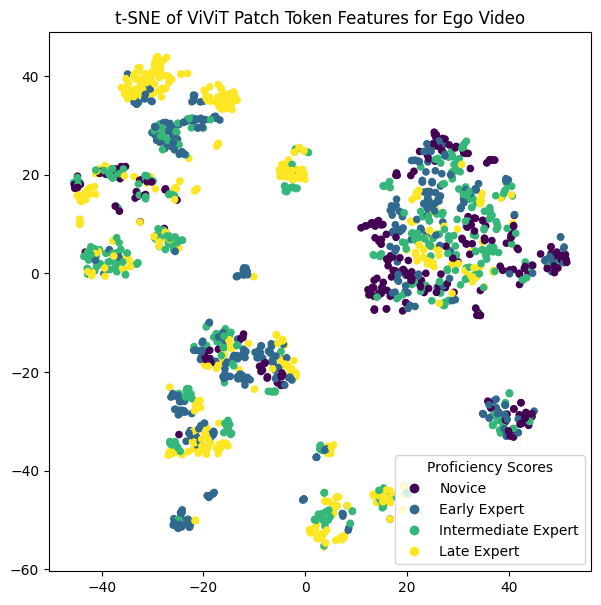

In [18]:
# features: (N, 3137, 768) torch tensor
# emb = features[:, 0].float().numpy()               # CLS token, (N, 768)
emb = features[:, 1:].mean(dim=1).float().numpy()   # mean of patch tokens

tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(emb) - 1),   # must be < N
    init="pca",
    learning_rate="auto",
    random_state=0,
)
coords = tsne.fit_transform(emb)                   # (N, 2)

plt.figure(figsize=(7, 7))
class_names = ["Novice", "Early Expert", "Intermediate Expert", "Late Expert"]
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=targets, s=20)
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=class_names, title="Proficiency Scores")
plt.title("t-SNE of ViViT Patch Token Features for Ego Video")
plt.savefig("vivit_tsne_patch_tokens.png")
plt.show()


In [14]:
ds = VideoDataset(proficiency_metadata, video_type='exo1', train=False)
loader = DataLoader(ds, batch_size=4, shuffle=False, num_workers=0,
                    pin_memory=True)

In [15]:
outputs = []
targets = []
with torch.inference_mode():
    for x_batch, y_batch in tqdm(loader):
        x = x_batch.to(model.device, non_blocking=True)
        out = model(pixel_values=x)
        outputs.append(out.last_hidden_state.cpu())
        targets.append(y_batch)

features = torch.cat(outputs)   # (N, 3137, 768)
targets = torch.cat(targets)

torch.save(features, "vivit_features_exo.pt")
torch.save(targets, "vivit_targets_exo.pt")

  0%|          | 0/414 [00:00<?, ?it/s]c:\Users\darkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 414/414 [1:45:52<00:00, 15.34s/it]


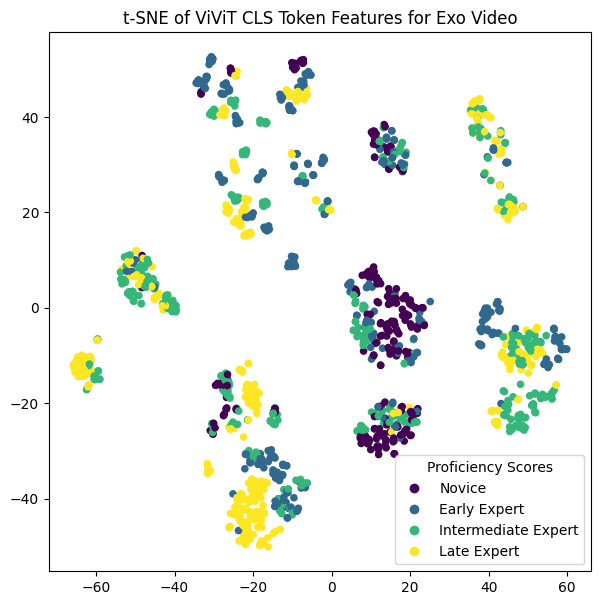

In [19]:
features = torch.load("vivit_features_exo.pt")
targets = torch.load("vivit_targets_exo.pt")

# features: (N, 3137, 768) torch tensor
emb = features[:, 0].float().numpy()               # CLS token, (N, 768)
# or: emb = features[:, 1:].mean(dim=1).float().numpy()   # mean of patch tokens

tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(emb) - 1),   # must be < N
    init="pca",
    learning_rate="auto",
    random_state=0,
)
coords = tsne.fit_transform(emb)                   # (N, 2)

plt.figure(figsize=(7, 7))
class_names = ["Novice", "Early Expert", "Intermediate Expert", "Late Expert"]
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=targets, s=20)
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=class_names, title="Proficiency Scores")
plt.title("t-SNE of ViViT CLS Token Features for Exo Video")
plt.savefig("vivit_tsne_exo.png")
plt.show()


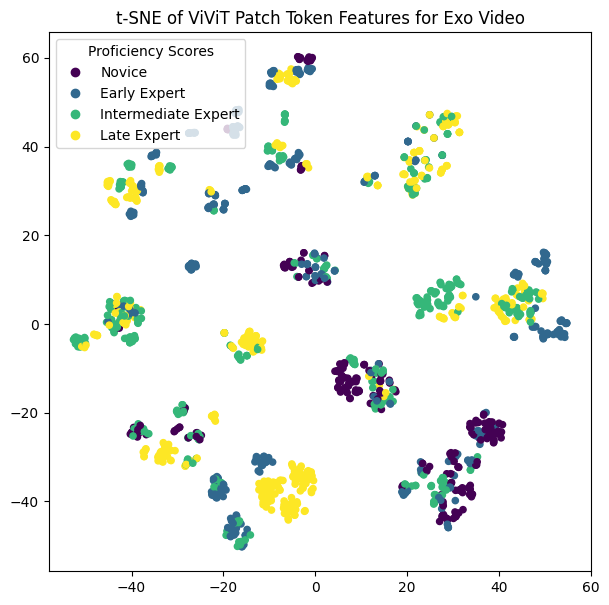

In [20]:
# features: (N, 3137, 768) torch tensor
# emb = features[:, 0].float().numpy()               # CLS token, (N, 768)
emb = features[:, 1:].mean(dim=1).float().numpy()   # mean of patch tokens

tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(emb) - 1),   # must be < N
    init="pca",
    learning_rate="auto",
    random_state=0,
)
coords = tsne.fit_transform(emb)                   # (N, 2)

plt.figure(figsize=(7, 7))
class_names = ["Novice", "Early Expert", "Intermediate Expert", "Late Expert"]
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=targets, s=20)
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=class_names, title="Proficiency Scores")
plt.title("t-SNE of ViViT Patch Token Features for Exo Video")
plt.savefig("vivit_tsne_exo_patch_tokens.png")
plt.show()